In [1]:
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
df = sns.load_dataset('iris')
df.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
df_s= df[df['species']!='setosa']

In [4]:
df_s.head()

,sepal_length,sepal_width,petal_length,petal_width,species
50,7.0,3.2,4.7,1.4,versicolor
51,6.4,3.2,4.5,1.5,versicolor
52,6.9,3.1,4.9,1.5,versicolor
53,5.5,2.3,4.0,1.3,versicolor
54,6.5,2.8,4.6,1.5,versicolor


In [5]:
df_s['species']=df_s['species'].map({'versicolor':0,'virginica':1})

In [6]:
df_s.head()

,sepal_length,sepal_width,petal_length,petal_width,species
50,7.0,3.2,4.7,1.4,0
51,6.4,3.2,4.5,1.5,0
52,6.9,3.1,4.9,1.5,0
53,5.5,2.3,4.0,1.3,0
54,6.5,2.8,4.6,1.5,0


In [7]:
# Split data
X = df_s.iloc[:,:-1]
y = df_s.iloc[:,-1]

In [8]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=31)


In [9]:
df_s.corr()

,sepal_length,sepal_width,petal_length,petal_width,species
sepal_length,1.000000,0.553855,0.828479,0.593709,0.494305
sepal_width,0.553855,1.000000,0.519802,0.566203,0.308080
petal_length,0.828479,0.519802,1.000000,0.823348,0.786424
petal_width,0.593709,0.566203,0.823348,1.000000,0.828129
species,0.494305,0.308080,0.786424,0.828129,1.000000


In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

#Scaling
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

classifier = LogisticRegression()
parameter = [
    {'l1_ratio':['1.0'],'solver':['liblinear','saga'],
     'C':[1,2,3,4,5],'max_iter':[1000]},
    {'l1_ratio':['0.0'],'solver':['lbfgs','liblinear','saga'],
     'C':[1,2,3,4,5],'max_iter':[1000]},
    {
        # ElasticNet (Combination of L1 and L2)
        'penalty': ['elasticnet'],
        'solver': ['saga'],
        'l1_ratio': [0.5], # Must be a float
        'C': [1, 2, 3, 4, 5]
    }
]
grid = GridSearchCV(classifier,param_grid=parameter,cv=5,scoring='accuracy')
grid.fit(X_train,y_train)
print("Best Parametrs:",grid.best_params_)
print("Best Score",grid.best_score_)

Best Parametrs: {'C': 1, 'l1_ratio': 0.5, 'penalty': 'elasticnet', 'solver': 'saga'}
Best Score 0.9866666666666667


/workspaces/SML/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/workspaces/SML/.venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/workspaces/SML/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/wor

In [11]:
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)
import matplotlib.pyplot as plt
#use the model
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
y_prob =grid.best_estimator_.predict_proba(X_test)[:,1]
accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
print("Accuracy:",accuracy)
print("precision;",precision)
print("recall:",recall)
print("f1:",f1)

Accuracy: 0.84
precision; 0.6666666666666666
recall: 1.0
f1: 0.8


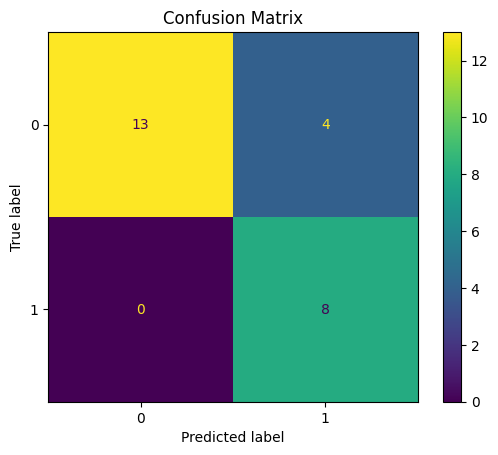

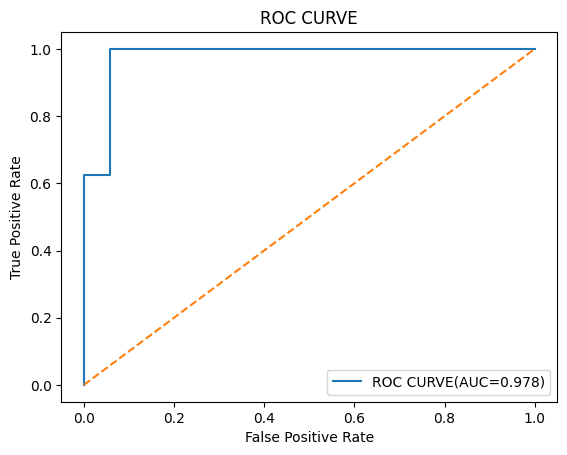

In [12]:
cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Confusion Matrix')
plt.show()
fpr,tpr,thresholds=roc_curve(y_test,y_prob)
roc_auc = roc_auc_score(y_test,y_prob)

plt.figure()
plt.plot(fpr,tpr,label=f"ROC CURVE(AUC={roc_auc:.3f})")
plt.plot([0,1],[0,1],linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC CURVE')
plt.legend()
plt.show()



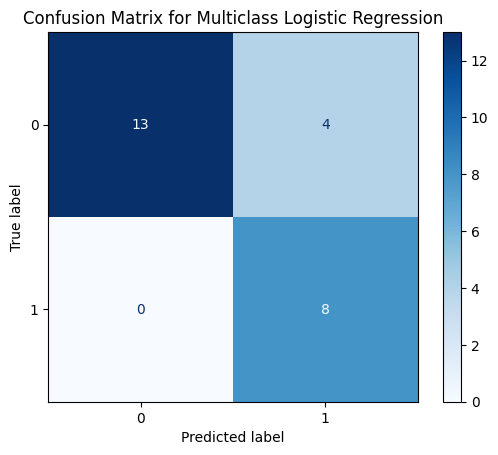

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix for Multiclass Logistic Regression")
plt.show()

MUTLTICLASS Classification

In [14]:
df = sns.load_dataset('iris')
df.head()
df = sns.load_dataset('iris')
df.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [15]:
from sklearn.preprocessing import LabelEncoder
le =LabelEncoder()
y = le.fit_transform(y)




In [16]:
# Split data
X = df_s.iloc[:,:-1]
y = df_s.iloc[:,-1]

In [34]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42,stratify=y)

In [35]:
sc = StandardScaler()
X_train= sc.fit_transform(X_train)
X_test= sc.transform(X_test)

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
import numpy as np

# Initialize with penalty='elasticnet' to allow l1_ratio to work
# 'saga' is the only solver that supports the full l1_ratio range
classifier = LogisticRegression(penalty='elasticnet', solver='saga', max_iter=5000)

parameter = [
    {
        # This covers L1, L2, and everything in between (ElasticNet)
        'l1_ratio': [0.0, 0.5, 1.0], 
        'C': [0.1, 1, 10]
    },
    {
        # If you specifically need 'liblinear' (which doesn't use l1_ratio)
        # you can still define it separately like this:
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear'],
        'C': [0.1, 1, 10]
    }
]

grid = GridSearchCV(classifier, param_grid=parameter, cv=5)
grid.fit(X_train_scaled, y_train)

/workspaces/SML/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/workspaces/SML/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/workspaces/SML/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this w

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...solver='saga')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'C': [0.1, 1, ...], 'l1_ratio': [0.0, 0.5, ...]}, {'C': [0.1, 1, ...], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and paramet

In [37]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test_scaled)


In [38]:
from sklearn.metrics import accuracy_score
print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.36


In [39]:
from sklearn.metrics import classification_report
print("\nClassifcation Report:\n")
print(classification_report(y_test,y_pred))





Classifcation Report:

              precision    recall  f1-score   support

           0       0.33      0.23      0.27        13
           1       0.38      0.50      0.43        12

    accuracy                           0.36        25
   macro avg       0.35      0.37      0.35        25
weighted avg       0.35      0.36      0.35        25



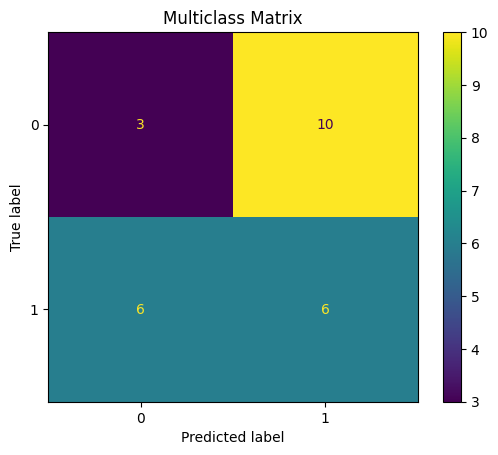

In [40]:
cm = confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=le.classes_)
disp.plot()
plt.title('Multiclass Matrix')
plt.show()



In [41]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.preprocessing import label_binarize

In [42]:
y_score = best_model.predict_proba(X_test)
print(y_score.shape) # Should be (Number of samples, 3)

(25, 2)


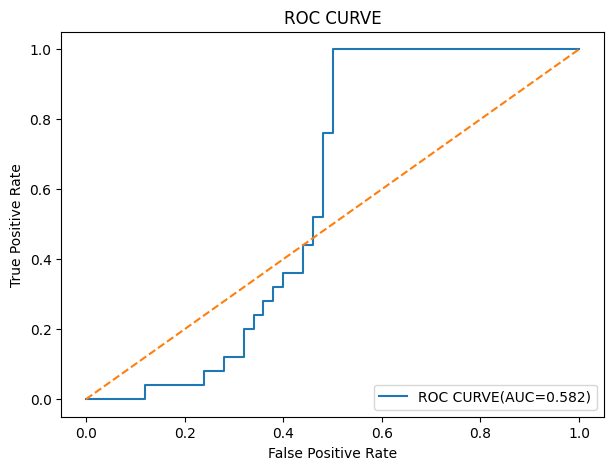

In [ ]:
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# 1. Force the labels to have 3 columns (Shape: 25, 3)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# 2. Get your current scores (Shape: 25, 2)
y_score = best_model.predict_proba(X_test)


# We add a column of 0.0 for the missing class
if y_score.shape[1] == 2:
    zero_column = np.zeros((y_score.shape[0], 1))
    y_score_3 = np.hstack([y_score, zero_column])
else:
    y_score_3 = y_score

# 4. Flatten both to (75,) so they match perfectly
fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score_3.ravel())
roc_auc = auc(fpr, tpr)

# 5. Plotting to match your image exactly
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'ROC CURVE(AUC={roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC CURVE')
plt.legend(loc="lower right")
plt.show()